In [112]:
import os
os.environ["OMP_NUM_THREADS"] = '2'

In [118]:
import numpy as np 
import pandas as pd
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



In [119]:

df = pd.read_csv("../data/Diabetes_and_Lifestyle_Dataset_.csv") #Loads the data set 

In [120]:

df.head(10).T #Inspects the database structure in a way that is easy to use and is correct before we start scaling

,0,1,2,3,4,5,6,7,8,9
Age,58,52,60,74,46,46,75,62,37,59
gender,Male,Female,Male,Female,Male,Female,Female,Male,Male,Female
ethnicity,Asian,White,Hispanic,Black,White,White,White,White,Black,White
education_level,Highschool,Highschool,Highschool,Highschool,Graduate,Highschool,Graduate,Postgraduate,Highschool,Graduate
income_level,Lower-Middle,Middle,Middle,Low,Middle,Upper-Middle,Upper-Middle,Middle,Lower-Middle,Middle
employment_status,Employed,Employed,Unemployed,Retired,Retired,Employed,Retired,Unemployed,Employed,Employed
smoking_status,Never,Former,Never,Never,Never,Never,Never,Current,Current,Current
alcohol_consumption_per_week,0,1,1,0,1,2,0,1,1,3
physical_activity_minutes_per_week,215,143,57,49,109,124,53,75,114,86
diet_score,5.7,6.7,6.4,3.4,7.2,9.0,9.2,4.1,6.7,8.2


In [121]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

None

In [122]:
df.isnull().sum() #Missing value check

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [123]:
features=["Age","bmi","waist_to_hip_ratio","systolic_bp","diastolic_bp","glucose_fasting","hba1c","physical_activity_minutes_per_week","diet_score"]
#Selects the clustering features

In [124]:
df = df.dropna(subset =features) #Drops missing values for features

In [125]:
data = df[features].copy() #Create a dataset for clustering

In [126]:
missing_cols = [col for col in features if col not in df.columns]
print("Missing columns:", missing_cols) 
#This verifies that all the features we using for clustering actually exist in the data set 
#This step ensures that the clustering model uses the correct diabeted-related variables

Missing columns: []


In [127]:
features = df[["Age","bmi","waist_to_hip_ratio","systolic_bp","diastolic_bp","glucose_fasting","hba1c","physical_activity_minutes_per_week","diet_score"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features) # This is to scale the features 

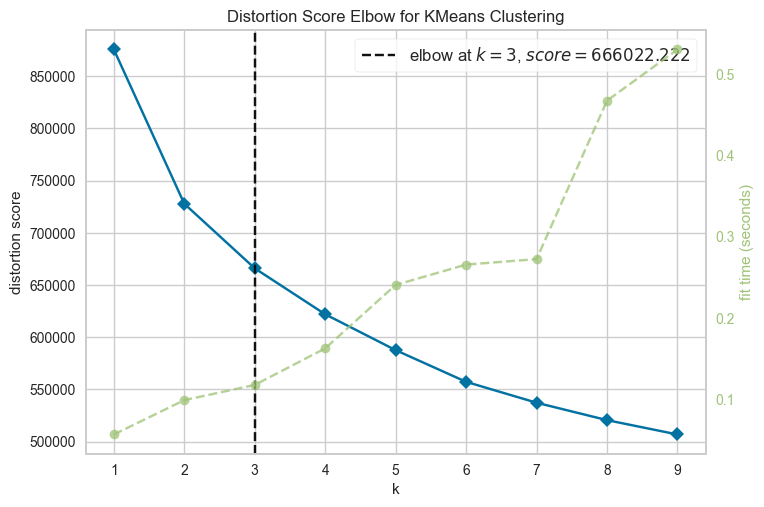

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [128]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))

visualizer.fit(scaled_features)    # Fit the data to the visualizer This is done to see the value of k and the average score
visualizer.poof()

In [140]:
k=3
kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)
df.head().T
#The elbow mwthod suggested that k=3 as an appropriate number of clusters , therefore K-means was applied 
#to segment patients into three distinct lifestyle risk-groups 


,0,1,2,3,4
Age,58,52,60,74,46
gender,Male,Female,Male,Female,Male
ethnicity,Asian,White,Hispanic,Black,White
education_level,Highschool,Highschool,Highschool,Highschool,Graduate
income_level,Lower-Middle,Middle,Middle,Low,Middle
employment_status,Employed,Employed,Unemployed,Retired,Retired
smoking_status,Never,Former,Never,Never,Never
alcohol_consumption_per_week,0,1,1,0,1
physical_activity_minutes_per_week,215,143,57,49,109
diet_score,5.7,6.7,6.4,3.4,7.2


 The transpose dataset preview (df.head().T) confirms that each record represents a record with demographic , lifestyle and clinical health attributes
relevant to diabetes rsik analysis . Key variables such as age,BMI ,blood pressure,fasting glucose ,HbA1c,physical activity ,diet score
noticeable variation across patients.
#Several patients display elevated fasting glucose and HbA1c values, indicating the presence of individuals at high risk of diabetes or already classified as Type 2 diabetes.
#K-Means clustering k=3 was applied to assign each patient to one to three distinct clusters , enabling further profiling of lifestyle -based diabeted risk groups

In [131]:
display(df.describe().T) #Displays various descriptive statistics from the dataset, including the mean/standard deviation, mmin, max, etc.

,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
diet_score,97297.0,5.995214,1.780096,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,97297.0,6.997708,1.093726,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,97297.0,0.219657,0.414017,0.00,0.00,0.00,0.00,1.00
hypertension_history,97297.0,0.250912,0.433540,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,97297.0,0.079067,0.269845,0.00,0.00,0.00,0.00,1.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20


The data set contains 97.297 records with no missing values in the numeric variables . The average 50 years and the mean BMI is 25,6 showing an overall overweight population . The mean fasting glucose is 111 mg/dL and mean HBA1c is 6.25% , which suggests many patients fall near or within dibetic risk thresholds . Lifestyle variable such as physical activity (rounded to 119 minutes/week) and the diet score (mean rounded to 6.0/10) show moderate health behaviour patterns . These statistics confirm the dataset is suitable for clustering into diabetes life-risk groups.

In [132]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
cluster_profile       #It splits the dataset into groups based on cluster labels (0, 1, 2, etc.) and calculates the mean of each feature per cluster.

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster,,,,,,,,,,,,,,,,,,,,,
0,44.000750,2.015913,129.281963,6.583692,6.994759,5.998469,0.187437,0.220560,0.063507,22.499994,...,177.344634,56.005650,93.157802,106.025224,105.869209,151.329816,7.327653,6.256709,25.526913,0.470236
1,60.579862,2.009626,101.518839,5.848834,6.997231,6.047349,0.324309,0.304843,0.107655,26.673164,...,194.077128,53.058304,111.500688,127.637953,122.612834,181.909549,9.805885,7.169144,36.172162,0.904141
2,46.005455,1.985778,126.022153,5.472392,7.001653,5.940257,0.142456,0.227086,0.065823,28.072486,...,187.150755,52.844795,105.116956,132.632467,104.635244,146.118060,10.265825,6.115855,29.156226,0.417696


The data is split into three clusters . Cluster 0 represents low-risk individuals with better life style habits and lower glucose levels.Cluster 1 represents high-risk inviduals with higher age , BMI , glucose and diabetes prevelance . Cluster 2 is a moderate risk group with mixed health indicators.Cluster 2 is in the middle with moderate values for most indicators but a higher BMI than cluster 0 and lower risk than cluster 1 
. Overall , the clusters clearly seperate low,meduim and high diabetes risk profiles.

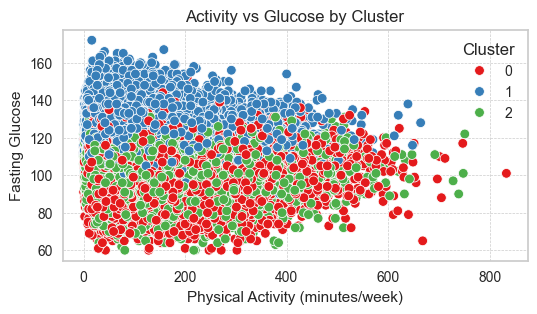

In [133]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=df,
    x="physical_activity_minutes_per_week",
    y="glucose_fasting",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("Physical Activity (minutes/week)")
plt.ylabel("Fasting Glucose")
plt.title("Activity vs Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

The scatter plot show clear seperation mainly by fasting glucose . cluster 1 (blue) has the highest glucose value (high-risk group) ,Cluster 0 (red) has the lowest glucose values(low-risk group) , and Cluster 2(green) falls in between (moderate risk) . Physical activity overlaps across clusters ,meaning glucose is the strongest factor driving the segmentation 

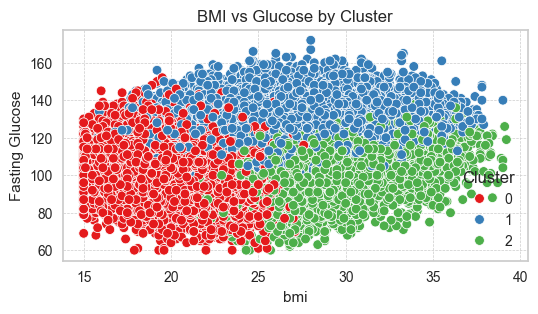

In [134]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=df,
    x="bmi",
    y="glucose_fasting",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("bmi")
plt.ylabel("Fasting Glucose")
plt.title("BMI vs Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

BMI and glucose fasting show a strong cluster seperation . Mainly low BMI/low glucose , Cluster 2 moderate glucose with higher BMI , and Cluster 1 contains the highest glucose values across BMI ranges , indicating the highest-risk group.

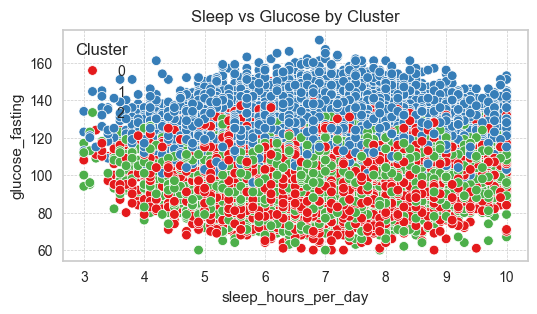

In [135]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=df,
    x="sleep_hours_per_day",
    y="glucose_fasting",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("sleep_hours_per_day")
plt.ylabel("glucose_fasting")
plt.title("Sleep vs Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Fasting glucose clearly seperates the clusters , while sleep hours overlap across all groups. Cluster 1 shows shows consistently higher glucose (high-risk),Cluster 0 lower glucose (low-risk),and Cluster 2 moderate levels . This suggests that sleep is not strong clustering factor compared to glucose

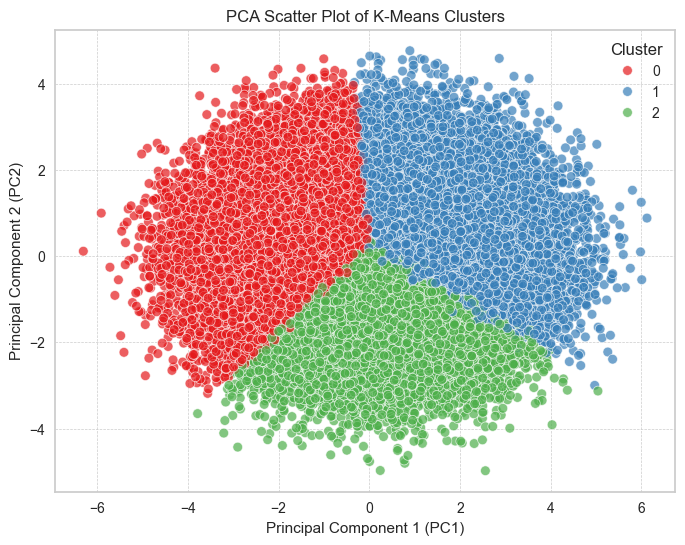

In [143]:
# Apply PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Create dataframe for plotting
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]

# Plot PCA scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1", alpha=0.7)
plt.title("PCA Scatter Plot of K-Means Clusters")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

The PCA scatter plot reduces the multi-dimensional dataset into two principal componenets PC1 and PC2 to make the clusters in two dimension . The plot shows three clearly seperated groups , confirming that K- means sucessfully segmented the patients into three distinct lifestyle/clinical risk profiles.Cluster0(red) is seperated on the left side lower(PC1) , indicating a distinct patient group with similar characteristics . 
Cluster1(blue) appears on the right side(higher PC1 values) , showing another clearly diffirent patient segment .Cluster2 (green) is concentrated towards the buttom (lower PC2 values ), forming a third unique group